# GF180MCUD Vgs sweep

# Preparation

In [1]:
%%writefile .spiceinit
set ngbehavior=hs

Writing .spiceinit


# PMOS simulation

## Create NGSPICE netlist

In [2]:
%%writefile pmos_netlist.spice
* PMOS VGS sweep
* Please Modify include and lib path according to your enviroment.
.include "/foss/pdks/gf180mcuD/libs.tech/ngspice/design.ngspice"
.lib "/foss/pdks/gf180mcuD/libs.tech/ngspice/sm141064.ngspice" typical

* MOS parameter
.param mos_l=0.28u
.param mos_w=1u
.param mos_nf=ceil(1)
.param mos_m=ceil(1)
.param mos_ad={ceil((mos_nf+1)/2)*mos_w/mos_nf*0.18u}
.param mos_as={ceil((mos_nf+2)/2)*mos_w/mos_nf*0.18u}
.param mos_pd={2*ceil((mos_nf+1)/2)*(mos_w/mos_nf+0.18u)}
.param mos_ps={2*ceil((mos_nf+2)/2)*(mos_w/mos_nf+0.18u)}
.param mos_nrd={0.18u/mos_w}
.param mos_nrs={0.18u/mos_w}
.param mos_sa=0
.param mos_sb=0 
.param mos_sd=0   
XM1 D G S B pfet_03v3 L=mos_l W=mos_w  nf=mos_nf ad=mos_ad as=mos_as pd=mos_pd ps=mos_ps nrd=mos_nrd nrs=mos_nrs sa=mos_sa sb=mos_sb sd=mos_sd m=mos_m
vg 0 g dc 1 ac 1
vd 0 d 3.3
vs 0 s 0
vb 0 b 0
.op
.option post nomod
.end
.control
option savecurrents
save all
* DC alanysis to obtain id vs Vgs
dc vg 0 3.3 0.001
display
set wr_vecnames               ; for wrdata: write the vector names
wrdata pmos_output_dc.txt i(vd)

* AC analysis from 1Hz to 1GHz to obtain Cgg
ac dec 10 1 1G
let cgg = imag(i(vg)) / (2 * pi * frequency)
set wr_vecnames               ; for wrdata: write the vector names
wrdata pmos_output_ac.txt cgg

.endc

Writing pmos_netlist.spice


## Execute NGSPICE simulation

In [9]:
!ngspice -b pmos_netlist.spice


Note: Compatibility modes selected: hs



Circuit: * pmos vgs sweep

Doing analysis at TEMP = 27.000000 and TNOM = 27.000000

Using SPARSE 1.3 as Direct Linear Solver
 Reference value :  2.71900e+00
No. of Data Rows : 3301
Here are the vectors currently active:

Title: * pmos vgs sweep
Name: dc1 (DC transfer characteristic)
Date: Sun May 24 13:34:07  2026

    b                   : voltage, real, 3301 long
    d                   : voltage, real, 3301 long
    g                   : voltage, real, 3301 long
    s                   : voltage, real, 3301 long
    v-sweep             : voltage, real, 3301 long [default scale]
    vb#branch           : current, real, 3301 long
    vd#branch           : current, real, 3301 long
    vg#branch           : current, real, 3301 long
    vs#branch           : current, real, 3301 long
Doing analysis at TEMP = 27.000000 and TNOM = 27.000000

Using SPARSE 1.3 as Direct Linear Solver
 Reference value :  1.00000e+00
No. of Data Rows : 91
Doing analysi

## Visualize PMOS characteristics

## Load PMOS simulation result

In [16]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pmos_w=1e-6
pmos_df = pd.read_csv("pmos_output_dc.txt", sep=r"\s+", header=0)
pmos_df.columns = ["vgs", "id"]
pmos_df['id'] = pmos_df['id']*-1
pmos_df['gm'] = np.gradient(pmos_df['id'])/np.gradient(pmos_df['vgs']);
pmos_df['gm_id'] = pmos_df['gm']/pmos_df['id']

pmos_ac_df = pd.read_csv("pmos_output_ac.txt", sep=r"\s+", header=0)
pmos_ac_df.columns = ["frequency", "cgg", "cgg2"]
pmos_cgg = pmos_ac_df["cgg"][0]*-1

pmos_df['f_T'] = pmos_df['gm']/pmos_cgg/2/math.pi
pmos_df['id_w'] = pmos_df['id']/pmos_w
pmos_df['f_T_gm_id'] = pmos_df['f_T']*pmos_df['gm_id']

## Plot -Vgs vs -id

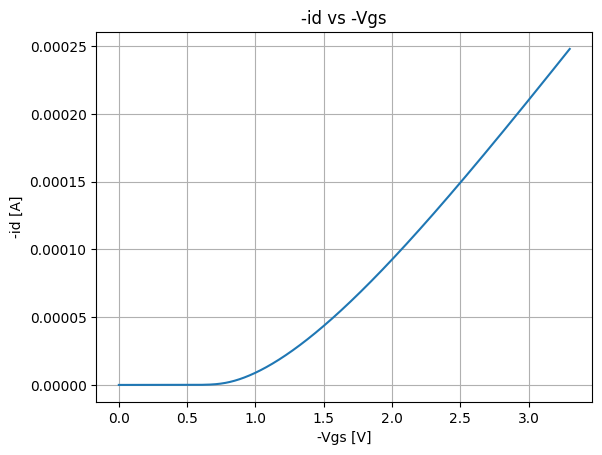

In [17]:
pmos_df.plot(x="vgs", y="id", grid=True,legend=False)
plt.title("-id vs -Vgs")
plt.ylabel("-id [A]")
plt.xlabel("-Vgs [V]")
plt.show()

## Plot gm vs Vgs

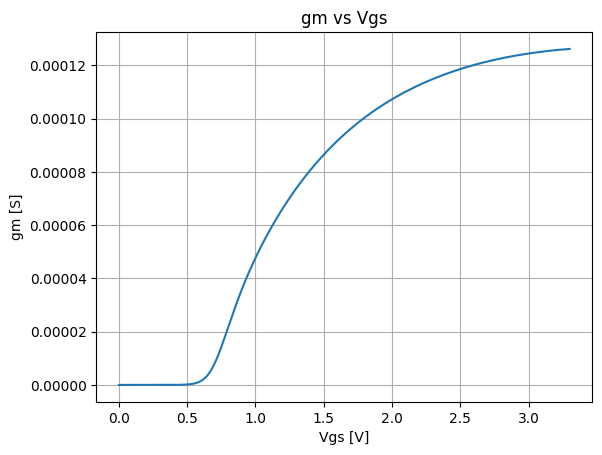

In [18]:
pmos_df.plot(x="vgs", y="gm", grid=True,legend=False)
plt.title("gm vs Vgs")
plt.ylabel("gm [S]")
plt.xlabel("Vgs [V]")
plt.show()

## Plot id/w vs gm/id

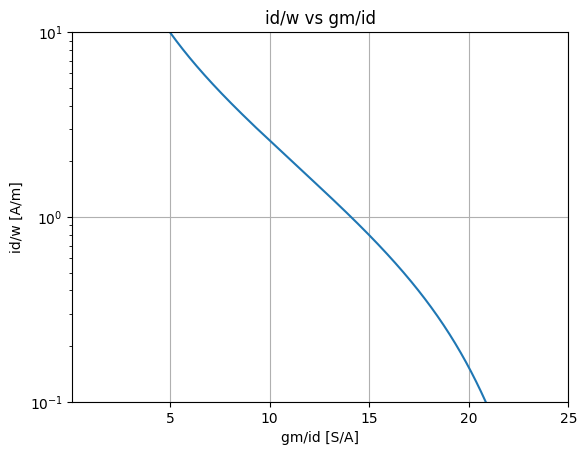

In [19]:
pmos_df.plot(x="gm_id", y="id_w",logy=True, grid=True,legend=False)
plt.title("id/w vs gm/id")
plt.ylim(1e-1,10)
plt.xlim(1e-1,25)

plt.ylabel("id/w [A/m]")
plt.xlabel("gm/id [S/A]")
plt.show()

## Calculate W from id and gm

In [20]:
# Returns interpolated Y for a given X_value using df columns
from scipy import interpolate
f_pmos_gm_id_to_id_w = interpolate.interp1d(pmos_df['gm_id'], pmos_df['id_w'])

#define design parameter
pmos_l = 0.28e-6
pmos_id = 100e-6
pmos_gm = 5.88235294117647e-05
pmos_gm_id=pmos_gm/pmos_id
pmos_id_w = f_pmos_gm_id_to_id_w(pmos_gm_id)
pmos_w = pmos_id/pmos_id_w
print(f"pmos_id: {pmos_id}")
print(f"pmos_gm: {pmos_gm}")
print(f"pmos_l: {pmos_l}")
print(f"pmos_w: {pmos_w}")


pmos_id: 0.0001
pmos_gm: 5.88235294117647e-05
pmos_l: 2.8e-07
pmos_w: 4.720742369155078e-07


## Plot -Vgs vs -gm/id

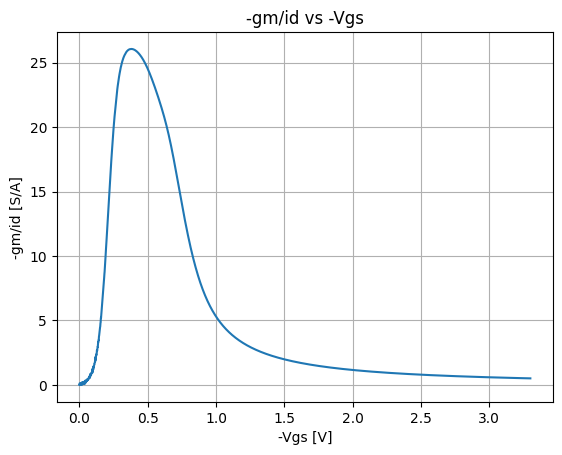

In [21]:
pmos_df.plot(x="vgs", y="gm_id", grid=True,legend=False)
plt.title("-gm/id vs -Vgs")
plt.ylabel("-gm/id [S/A]")
plt.xlabel("-Vgs [V]")
plt.show()

## Plot -Vgs vs f_T

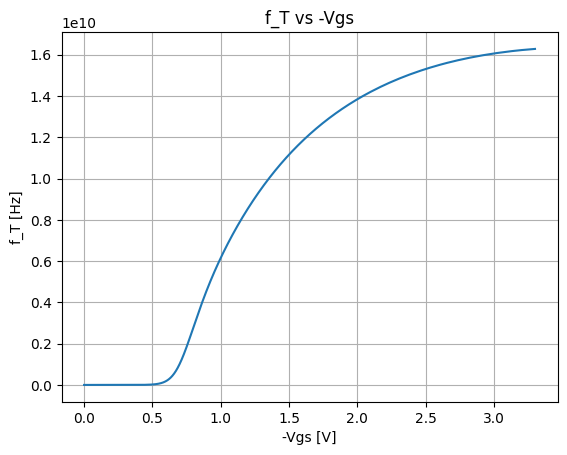

In [22]:
pmos_df.plot(x="vgs", y="f_T", grid=True,legend=False)
plt.title("f_T vs -Vgs")
plt.ylabel("f_T [Hz]")
plt.xlabel("-Vgs [V]")
plt.show()

## Plot f_T*gm/id vs gm/id

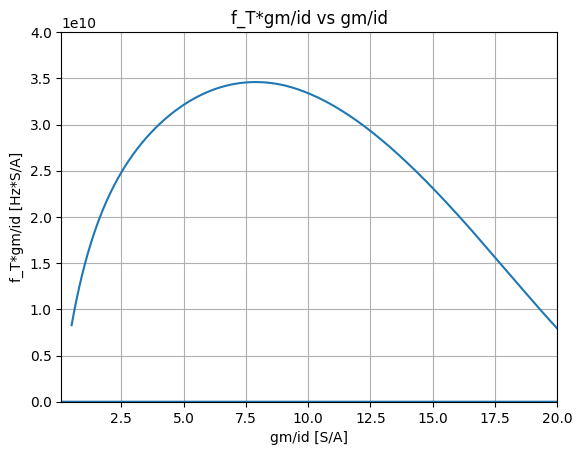

max
f_T*gm/id:34596027810.62444
gm/id:7.885356565251122


In [23]:
pmos_df.plot(x="gm_id", y="f_T_gm_id", grid=True,legend=False)
plt.title("f_T*gm/id vs gm/id")
plt.ylabel("f_T*gm/id [Hz*S/A]")
plt.xlabel("gm/id [S/A]")
plt.xlim(1e-1,20)
plt.ylim(1e-1,4e10)
plt.show()
pmos_max_index=np.argmax(pmos_df['f_T_gm_id'])
pmos_gm_id_on_max_f_T_gm_id = pmos_df['gm_id'][pmos_max_index]
pmos_max_f_T_gm_id = pmos_df['f_T_gm_id'][pmos_max_index]
print('max')
print(f'f_T*gm/id:{pmos_max_f_T_gm_id}')
print(f'gm/id:{pmos_gm_id_on_max_f_T_gm_id}')

## Calculate W and id from gm on Max f_T*gm/id

In [24]:
#define design parameter
pmos_gm=100e-6
pmos_gm_id=pmos_gm_id_on_max_f_T_gm_id
pmos_id=pmos_gm/pmos_gm_id 
pmos_id_w = f_pmos_gm_id_to_id_w(pmos_gm_id)
pmos_w = pmos_id/pmos_id_w
print(f"pmos_gm: {pmos_gm}")
print(f"pmos_id: {pmos_id}")
print(f"pmos_gm_id: {pmos_gm_id}")
print(f"pmos_l: {pmos_l}")
print(f"pmos_w: {pmos_w}")

pmos_gm: 0.0001
pmos_id: 1.2681734703117429e-05
pmos_gm_id: 7.885356565251122
pmos_l: 2.8e-07
pmos_w: 2.939955524352831e-06


# NMOS simulation

## Create NGSPICE netlist

In [25]:
%%writefile nmos_netlist.spice
* NMOS VGS sweep
* Please Modify include and lib path according to your enviroment.
.include "/foss/pdks/gf180mcuD/libs.tech/ngspice/design.ngspice"
.lib "/foss/pdks/gf180mcuD/libs.tech/ngspice/sm141064.ngspice" typical

* MOS parameter
.param mos_l=0.28u
.param mos_w=1u
.param mos_nf=ceil(1)
.param mos_m=ceil(1)
.param mos_ad={ceil((mos_nf+1)/2)*mos_w/mos_nf*0.18u}
.param mos_as={ceil((mos_nf+2)/2)*mos_w/mos_nf*0.18u}
.param mos_pd={2*ceil((mos_nf+1)/2)*(mos_w/mos_nf+0.18u)}
.param mos_ps={2*ceil((mos_nf+2)/2)*(mos_w/mos_nf+0.18u)}
.param mos_nrd={0.18u/mos_w}
.param mos_nrs={0.18u/mos_w}
.param mos_sa=0
.param mos_sb=0 
.param mos_sd=0   
XM1 D G S B nfet_03v3 L=mos_l W=mos_w  nf=mos_nf ad=mos_ad as=mos_as pd=mos_pd ps=mos_ps nrd=mos_nrd nrs=mos_nrs sa=mos_sa sb=mos_sb sd=mos_sd m=mos_m
vg g 0 dc 1 ac 1
vd d 0 3.3
vs s 0 0
vb b 0 0
.op
.option post nomod
.end
.control
* DC alanysis to obtain id vs Vgs
dc vg 0 3.3 0.001
display
set wr_vecnames               ; for wrdata: write the vector names
wrdata nmos_output_dc.txt i(vd)

* AC analysis from 1Hz to 1GHz to obtain Cgg
ac dec 10 1 1G
let cgg = imag(i(vg)) / (2 * pi * frequency)
set wr_vecnames               ; for wrdata: write the vector names
wrdata nmos_output_ac.txt cgg
.endc

Writing nmos_netlist.spice


## Execute NGSPICE simulation

In [26]:
!ngspice -b nmos_netlist.spice


Note: Compatibility modes selected: hs



Circuit: * nmos vgs sweep

Doing analysis at TEMP = 27.000000 and TNOM = 27.000000

Using SPARSE 1.3 as Direct Linear Solver
 Reference value :  2.83500e+00
No. of Data Rows : 3301
Here are the vectors currently active:

Title: * nmos vgs sweep
Name: dc1 (DC transfer characteristic)
Date: Sun May 24 13:37:11  2026

    b                   : voltage, real, 3301 long
    d                   : voltage, real, 3301 long
    g                   : voltage, real, 3301 long
    s                   : voltage, real, 3301 long
    v-sweep             : voltage, real, 3301 long [default scale]
    vb#branch           : current, real, 3301 long
    vd#branch           : current, real, 3301 long
    vg#branch           : current, real, 3301 long
    vs#branch           : current, real, 3301 long
Doing analysis at TEMP = 27.000000 and TNOM = 27.000000

Using SPARSE 1.3 as Direct Linear Solver
 Reference value :  1.25893e+02
No. of Data Rows : 91
Doing analysi

## Visualize NMOS characteristics

## Load NMOS simulation result

In [28]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
nmos_w=1e-6
nmos_df = pd.read_csv("nmos_output_dc.txt", sep=r"\s+", header=0)
nmos_df.columns = ["vgs", "id"]
nmos_df['id'] = nmos_df['id']*-1
nmos_df['gm'] = np.gradient(nmos_df['id'])/np.gradient(nmos_df['vgs']);
nmos_df['gm_id'] = nmos_df['gm']/nmos_df['id']

nmos_ac_df = pd.read_csv("nmos_output_ac.txt", sep=r"\s+", header=0)
nmos_ac_df.columns = ["frequency", "cgg", "cgg2"]
nmos_cgg = nmos_ac_df["cgg"][0]*-1

nmos_df['f_T'] = nmos_df['gm']/nmos_cgg/2/math.pi
nmos_df['id_w'] = nmos_df['id']/nmos_w
nmos_df['f_T_gm_id'] = nmos_df['f_T']*nmos_df['gm_id']

## Plot Vgs vs id

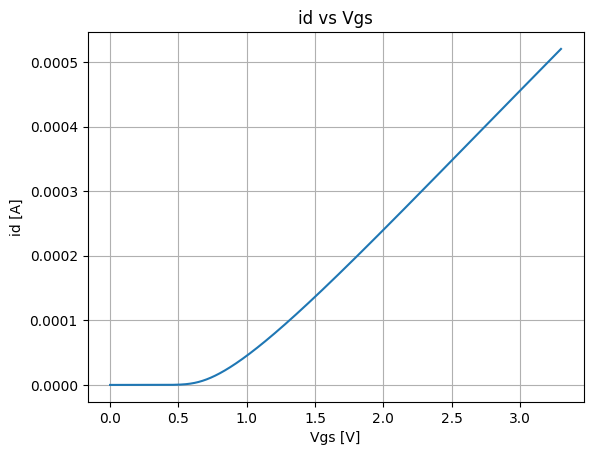

In [29]:
nmos_df.plot(x="vgs", y="id", grid=True,legend=False)
plt.title("id vs Vgs")
plt.ylabel("id [A]")
plt.xlabel("Vgs [V]")
plt.show()

## Plot gm vs Vgs

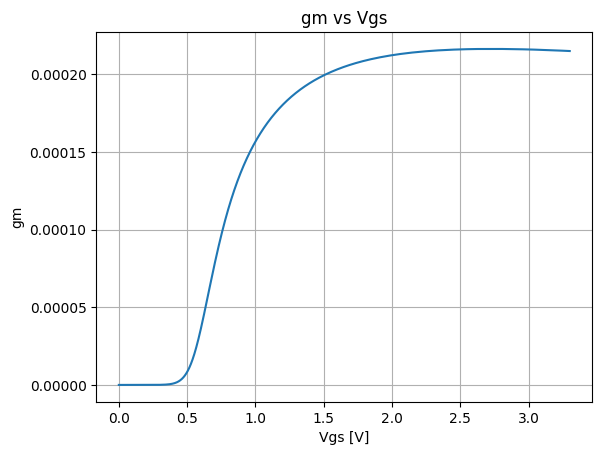

In [30]:
nmos_df.plot(x="vgs", y="gm", grid=True,legend=False)
plt.title("gm vs Vgs")
plt.ylabel("gm")
plt.xlabel("Vgs [V]")
plt.show()

## Plot id/w vs gm/id

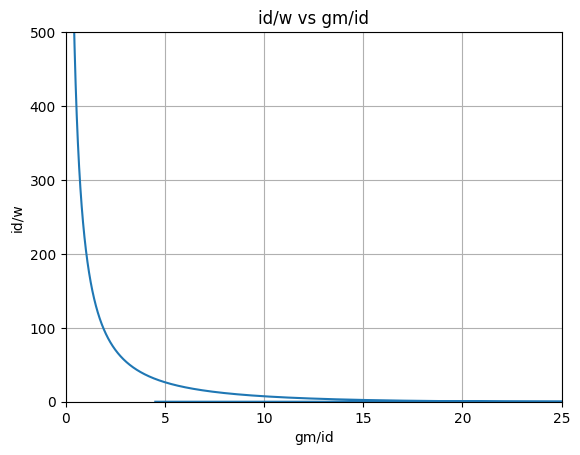

In [31]:
nmos_df.plot(x="gm_id", y="id_w", grid=True,legend=False)
plt.xlim(0, 25)
plt.ylim(0,50e1)
plt.title("id/w vs gm/id")
plt.ylabel("id/w")
plt.xlabel("gm/id")
plt.show()

## Calculate W from id and gm

In [32]:
# Returns interpolated Y for a given X_value using df columns
from scipy import interpolate
f_nmos_gm_id_to_id_w = interpolate.interp1d(nmos_df['gm_id'], nmos_df['id_w'])

#define design parameter
nmos_l = 0.28e-6
nmos_id = 100e-6
nmos_gm = 1000e-6
nmos_gm_id=nmos_gm/nmos_id
nmos_id_w = f_nmos_gm_id_to_id_w(nmos_gm_id)
nmos_w = nmos_id/nmos_id_w
print(f"nmos_id: {nmos_id}")
print(f"nmos_gm: {nmos_gm}")
print(f"nmos_l: {nmos_l}")
print(f"nmos_w: {nmos_w}")

nmos_id: 0.0001
nmos_gm: 0.001
nmos_l: 2.8e-07
nmos_w: 1.3581384771979583e-05


## Plot Vgs vs gm/id

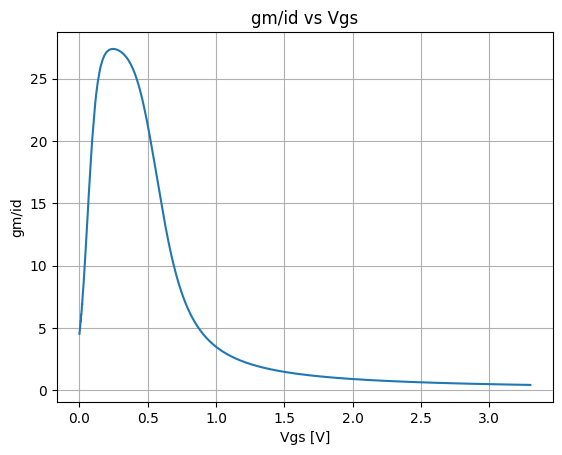

In [33]:
nmos_df.plot(x="vgs", y="gm_id", grid=True,legend=False)
plt.title("gm/id vs Vgs")
plt.ylabel("gm/id")
plt.xlabel("Vgs [V]")
plt.show()

## Plot -Vgs vs f_T

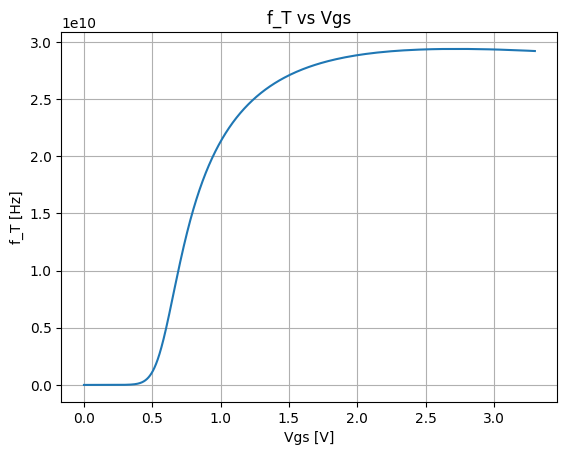

In [34]:
nmos_df.plot(x="vgs", y="f_T", grid=True,legend=False)
plt.title("f_T vs Vgs")
plt.ylabel("f_T [Hz]")
plt.xlabel("Vgs [V]")
plt.show()

## Plot f_T*gm/id vs gm/id

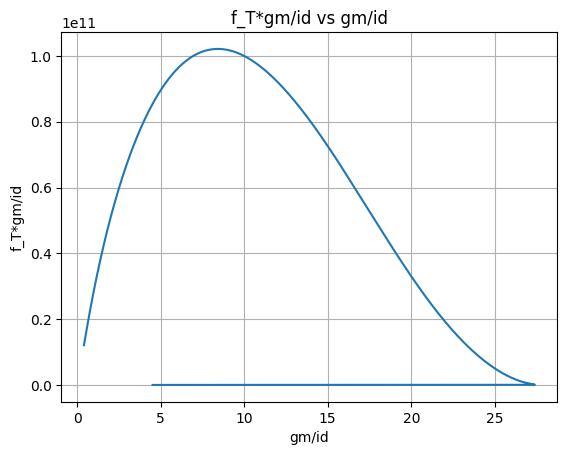

max
f_T*gm/id:22580723518.27717
gm/id:8.432472702171244


In [35]:
nmos_df.plot(x="gm_id", y="f_T_gm_id", grid=True,legend=False)
plt.title("f_T*gm/id vs gm/id")
plt.ylabel("f_T*gm/id")
plt.xlabel("gm/id")
plt.show()
nmos_max_index=np.argmax(nmos_df['f_T_gm_id'])
nmos_gm_id_on_max_f_T_gm_id = nmos_df['gm_id'][nmos_max_index]
nmos_max_f_T_gm_id = pmos_df['f_T_gm_id'][nmos_max_index]
print('max')
print(f'f_T*gm/id:{nmos_max_f_T_gm_id}')
print(f'gm/id:{nmos_gm_id_on_max_f_T_gm_id}')

## Calculate W and id from gm on Max f_T*gm/id

In [36]:
#define design parameter
nmos_gm=100e-6
nmos_gm_id=nmos_gm_id_on_max_f_T_gm_id
nmos_id=nmos_gm/nmos_gm_id 
nmos_id_w = f_nmos_gm_id_to_id_w(nmos_gm_id)
nmos_w = nmos_id/nmos_id_w
print(f"nmos_gm: {nmos_gm}")
print(f"nmos_id: {nmos_id}")
print(f"nmos_gm_id: {nmos_gm_id}")
print(f"nmos_l: {nmos_l}")
print(f"nmos_w: {nmos_w}")

nmos_gm: 0.0001
nmos_id: 1.1858917725787763e-05
nmos_gm_id: 8.432472702171244
nmos_l: 2.8e-07
nmos_w: 1.121306905624644e-06
